# Atoti DataMart & Widget Visualization

**Authors:**
- Mylovia Mahesa Ayu
- Abdullah Al-Firdaus Nuzula
- Fio Octriyanti
- Muhammad Raffi Fahrezi  

**Course:** Data Warehouse - S1 Sains Data, UNESA  
**Stage:** Data Presentation (Atoti DataMart + Atoti Widgets)

This notebook is the **presentation layer** of the data warehouse pipeline. The
Extract–Transform–Load stages have already populated a cloud-hosted PostgreSQL
database (Supabase) with a dimensional model. Here we connect to that database,
load the fact and dimension tables into an **Atoti session**, build **OLAP cubes**,
and explore the data through interactive **Atoti widgets**.

**What this notebook does, end to end:**

1. **Connect & load**, pull the fact and dimension tables out of Supabase into
   pandas DataFrames.
2. **Prepare types**, cast key/label columns to `object` so Atoti treats them as
   dimensions (text) rather than measures (numbers).
3. **Build the session & cubes**, register each fact table as an Atoti table and
   create one cube per analytical subject.
4. **Define hierarchies & measures**, set up the drill paths (Time, Geography,
   Fuel, Sector) and the aggregated measures the widgets will display.
5. **Visualize**, render interactive widgets that slice and dice the cubes.

**Why three cubes instead of one?** The three fact tables sit at **different
grains** (different combinations of keys), so they cannot be merged into a single
fact table without either losing detail or inflating rows. Keeping them as three
separate cubes; `WorldBank`, `EnergyEconomy`, and `Generation`; lets each measure
be aggregated at its natural grain.

In [1]:
import atoti as tt
import pandas as pd, os
from sqlalchemy import create_engine
from dotenv import load_dotenv

Welcome to Atoti 0.9.13!

By using this community edition, you agree with the license available at https://docs.activeviam.com/products/atoti/python-sdk/latest/eula.html.
Browse the official documentation at https://docs.activeviam.com/products/atoti/python-sdk.
Join the community at https://www.atoti.io/register.

Atoti collects telemetry data, which is used to help understand how to improve the product.
If you don't wish to send usage data, you can request a trial license at https://www.atoti.io/evaluation-license-request.

You can hide this message by setting the `ATOTI_HIDE_EULA_MESSAGE` environment variable to True.


In [ ]:
load_dotenv()
engine = create_engine(os.environ["DB_URL"])

fact_ee  = pd.read_sql("SELECT * FROM fact_energy_economy", engine)
fact_gen = pd.read_sql("SELECT * FROM fact_generation", engine)
dim_time    = pd.read_sql("SELECT * FROM dim_time", engine)
dim_sector  = pd.read_sql("SELECT * FROM dim_sector", engine)
dim_country = pd.read_sql("SELECT * FROM dim_country", engine)

print("fact_ee shape:", fact_ee.shape)
print("fact_gen shape:", fact_gen.shape)
print(fact_ee.columns.tolist())
print(fact_gen.columns.tolist())

In [3]:
dim_country.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   country_id    8 non-null      int64 
 1   country_code  8 non-null      object
 2   country_name  8 non-null      object
 3   region        8 non-null      object
 4   income_group  8 non-null      object
dtypes: int64(1), object(4)
memory usage: 452.0+ bytes


In [4]:
dim_country.head()


,country_id,country_code,country_name,region,income_group
0,1,US,United States,North America,High
1,2,CN,China,Asia Pacific,Upper-Middle
2,3,DE,Germany,Europe,High
3,4,JP,Japan,Asia Pacific,High
4,5,IN,India,Asia Pacific,Lower-Middle


In [5]:
fact_gen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   period              288 non-null    object 
 1   time_id             288 non-null    int64  
 2   fuel_type_id        288 non-null    object 
 3   fuel_name           288 non-null    object 
 4   fuel_category       288 non-null    object 
 5   is_renewable        288 non-null    bool   
 6   net_generation_mwh  288 non-null    float64
 7   year                288 non-null    int64  
dtypes: bool(1), float64(1), int64(2), object(4)
memory usage: 16.2+ KB


In [ ]:
for c in ["period", "country_code", "sector_id"]:
    fact_ee[c] = fact_ee[c].astype(str)
    
for c in ["period", "fuel_type_id", "fuel_name", "fuel_category"]:
    fact_gen[c] = fact_gen[c].astype(str)
    
for c in ["country_code", "country_name", "region", "income_group"]:
    dim_country[c] = dim_country[c].astype(str)

for df in [fact_ee, fact_gen]:
    df["year"]    = df["period"].str[:4].astype(int)
    df["quarter"] = ((df["period"].str[5:7].astype(int) - 1) // 3 + 1).astype(int)
    df["month"]   = df["period"].str[5:7].astype(int)

print("Types cast OK")

In [ ]:
session = tt.Session.start()

# Daftarkan fact tables
ee_tbl  = session.read_pandas(fact_ee,  
                              table_name="EnergyEconomy", 
                              keys=["period", "sector_id"])

gen_tbl = session.read_pandas(fact_gen, 
                              table_name="Generation",    
                              keys=["period", "fuel_type_id"])

ctry_tbl = session.read_pandas(dim_country, 
                               table_name="Country", 
                               keys=["country_code"])

# Join dim_country ke EnergyEconomy via country_code
ee_tbl.join(ctry_tbl, mapping={"country_code": "country_code"})

# Buat cube
cube_ee  = session.create_cube(ee_tbl,  "Energy Economy Cube")
cube_gen = session.create_cube(gen_tbl, "Generation Cube")

print("Session & cubes ready →", session.url)

In [8]:
print(list(cube_wb.levels))

[('WorldBank', 'country_name', 'country_name'), ('WorldBank', 'country_code', 'country_code'), ('WorldBank', 'period', 'period'), ('Country', 'region', 'region'), ('Country', 'country_name', 'country_name'), ('Country', 'income_group', 'income_group')]


In [ ]:
# Energy Economy Cube
he, le, me = cube_ee.hierarchies, cube_ee.levels, cube_ee.measures

he["Time"]      = {"Year": ee_tbl["year"], "Quarter": ee_tbl["quarter"], "Period": ee_tbl["period"]}
he["Sector"]    = {"Sector": ee_tbl["sector_id"]}
he["Geography"] = {"Region": ctry_tbl["region"], "Country": ctry_tbl["country_name"]}

me["Avg Price (cents/kWh)"]    = tt.agg.mean(ee_tbl["price_cents_kwh"])
me["Avg CPI (% YoY)"]          = tt.agg.mean(ee_tbl["cpi_pct_yoy"])
me["Avg Industrial Prod (USD)"]= tt.agg.mean(ee_tbl["industrial_prod_usd"])
me["Total Retail Sales (MWh)"] = tt.agg.sum(ee_tbl["retail_sales_mwh"])

# Generation Cube
hg, lg, mg = cube_gen.hierarchies, cube_gen.levels, cube_gen.measures

hg["Fuel"] = {"Category": gen_tbl["fuel_category"], "Fuel Type": gen_tbl["fuel_name"]}
hg["Time"] = {"Year": gen_tbl["year"], "Period": gen_tbl["period"]}

mg["Total Generation (MWh)"] = tt.agg.sum(gen_tbl["net_generation_mwh"])

print("Hierarchies & measures defined")

# Visualization Widgets

## Viz H2: Time Series Harga Listrik Industri vs CPI (AS)
**Hipotesis H2:** Harga listrik retail AS berkorelasi positif dengan CPI global.
- X axis: period (Jan 2022 – Des 2024)
- Filter Sector: IND (Industrial)
- Filter Country: US

In [ ]:
# H2: Time Series — Harga Listrik vs CPI
df_h2 = fact_ee[
    (fact_ee["sector_id"] == "IND") & 
    (fact_ee["country_code"] == "US")
].sort_values("period")

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14, 5))

color1 = "tab:blue"
ax1.set_xlabel("Period")
ax1.set_ylabel("Avg Price (cents/kWh)", color=color1)
ax1.plot(df_h2["period"], df_h2["price_cents_kwh"], color=color1, marker="o", markersize=3, label="Price (cents/kWh)")
ax1.tick_params(axis="y", labelcolor=color1)
plt.xticks(rotation=90)

ax2 = ax1.twinx()
color2 = "tab:red"
ax2.set_ylabel("CPI (% YoY)", color=color2)
ax2.plot(df_h2["period"], df_h2["cpi_pct_yoy"], color=color2, linestyle="--", marker="s", markersize=3, label="CPI (% YoY)")
ax2.tick_params(axis="y", labelcolor=color2)

fig.suptitle("H2: Harga Listrik Industri AS vs CPI (2022–2024)", fontsize=13, fontweight="bold")
fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.savefig("h2_price_vs_cpi.png", dpi=150)
plt.show()
print("Peak bersamaan di 2022-Q2/Q3 mendukung H2")

## Viz H3: Stacked Bar Bauran Energi per Tahun
**Hipotesis H3:** Ada pergeseran struktural bauran energi 2022–2024; proporsi Renewable naik, Fossil turun.

In [ ]:
# H3: Stacked Bar: Bauran Energi per Tahun
df_h3 = fact_gen.groupby(["year", "fuel_category"])["net_generation_mwh"].sum().reset_index()
df_pivot = df_h3.pivot(index="year", columns="fuel_category", values="net_generation_mwh").fillna(0)

col_order = [c for c in ["Fossil", "Nuclear", "Renewable", "Other"] if c in df_pivot.columns]
df_pivot = df_pivot[col_order]

fig, ax = plt.subplots(figsize=(8, 5))
df_pivot.plot(kind="bar", stacked=True, ax=ax, 
              colormap="Set2", edgecolor="white", linewidth=0.5)

ax.set_xlabel("Year")
ax.set_ylabel("Total Generation (MWh)")
ax.set_title("H3: Bauran Energi AS per Tahun (2022–2024)", fontsize=13, fontweight="bold")
ax.legend(title="Fuel Category", bbox_to_anchor=(1.01, 1))
ax.set_xticklabels(df_pivot.index, rotation=0)

for i, year in enumerate(df_pivot.index):
    total = df_pivot.loc[year].sum()
    renew = df_pivot.loc[year].get("Renewable", 0)
    pct   = renew / total * 100 if total > 0 else 0
    ax.text(i, total + total*0.01, f"Ren: {pct:.1f}%", ha="center", fontsize=9, color="green")

plt.tight_layout()
plt.savefig("h3_energy_mix.png", dpi=150)
plt.show()

## Viz H1: Heatmap Industrial Production vs Harga Listrik Industri (Quarterly)
**Hipotesis H1:** Lonjakan harga listrik industri AS 2022 berjalan seiring penurunan Industrial Production negara G7.

In [ ]:
# H1: Heatmap: Industrial Production per Negara per Quarter
import seaborn as sns

df_h1 = fact_ee.copy()
df_h1["quarter_label"] = df_h1["year"].astype(str) + "-Q" + df_h1["quarter"].astype(str)

heatmap_data = df_h1.groupby(["country_code", "quarter_label"])["industrial_prod_usd"] \
                    .mean().unstack().sort_index()

cols_sorted = sorted(heatmap_data.columns)
heatmap_data = heatmap_data[cols_sorted]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Subplot 1: Industrial Production
sns.heatmap(heatmap_data, ax=axes[0], cmap="YlOrRd_r", 
            annot=True, fmt=".0f", linewidths=0.4,
            cbar_kws={"label": "Avg Industrial Prod (USD)"})
axes[0].set_title("Industrial Production per Negara per Quarter", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Quarter")
axes[0].set_ylabel("Country")

# Subplot 2: Harga Listrik AS (IND) per quarter
price_us = df_h1[df_h1["sector_id"] == "IND"].groupby("quarter_label")["price_cents_kwh"].mean()
price_us = price_us[cols_sorted]
axes[1].bar(range(len(price_us)), price_us.values, color="steelblue", edgecolor="white")
axes[1].set_xticks(range(len(price_us)))
axes[1].set_xticklabels(price_us.index, rotation=90)
axes[1].set_ylabel("Avg Price US Industry (cents/kWh)")
axes[1].set_title("Harga Listrik Industri AS per Quarter", fontsize=11, fontweight="bold")
axes[1].axhspan(0, axes[1].get_ylim()[1] if axes[1].get_ylim()[1] > 0 else 10, alpha=0)

fig.suptitle("H1: Industrial Production G7 vs Harga Listrik AS (2022–2024)", 
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("h1_heatmap_indprod.png", dpi=150)
plt.show()

## Viz H4: Z-Score Anomaly Detection (Juni–Agustus 2022)
**Hipotesis H4:** Juni–Agustus 2022 adalah periode anomali simultan di semua indikator (Z-score > 2.0).

Langkah: hitung Z-score per indikator dari data US, lalu plot dengan threshold ±2.0.

In [ ]:
# H4: Z-Score Anomaly Detection
from scipy import stats

# Ambil data US saja, semua sektor dirata-rata
df_us = fact_ee[fact_ee["country_code"] == "US"].groupby("period").agg({
    "price_cents_kwh":   "mean",
    "cpi_pct_yoy":       "mean",
    "industrial_prod_usd":"mean",
    "retail_sales_mwh":  "mean"
}).reset_index().sort_values("period")

# Z-score
indicators = {
    "Price (cents/kWh)":      "price_cents_kwh",
    "CPI (% YoY)":            "cpi_pct_yoy",
    "Industrial Prod (USD)":  "industrial_prod_usd",
    "Retail Sales (MWh)":     "retail_sales_mwh",
}

fig, ax = plt.subplots(figsize=(15, 6))

colors = ["tab:blue", "tab:red", "tab:green", "tab:orange"]
for (label, col), color in zip(indicators.items(), colors):
    z = stats.zscore(df_us[col].fillna(df_us[col].mean()))
    ax.plot(df_us["period"], z, label=label, color=color, linewidth=1.5)

# Threshold lines
ax.axhline(y=2.0,  color="black", linestyle="--", linewidth=1, label="Z = ±2.0 (threshold)")
ax.axhline(y=-2.0, color="black", linestyle="--", linewidth=1)
ax.axhline(y=0,    color="gray",  linestyle="-",  linewidth=0.5)

anomaly_periods = ["2022-06", "2022-07", "2022-08"]
for p in anomaly_periods:
    if p in df_us["period"].values:
        idx = df_us[df_us["period"] == p].index[0]
        x_pos = df_us["period"].tolist().index(p)
        ax.axvspan(x_pos - 0.5, x_pos + 0.5, alpha=0.15, color="red")

ax.set_xlabel("Period")
ax.set_ylabel("Z-Score")
ax.set_title("H4: Z-Score Semua Indikator — Deteksi Anomali Jun–Agt 2022", 
             fontsize=13, fontweight="bold")
ax.legend(loc="upper right")
plt.xticks(ticks=range(0, len(df_us), 3), 
           labels=df_us["period"].values[::3], rotation=90)
plt.tight_layout()
plt.savefig("h4_zscore_anomaly.png", dpi=150)
plt.show()

print("\nAnomaly Periode (|Z| > 2.0)")
for label, col in indicators.items():
    z = stats.zscore(df_us[col].fillna(df_us[col].mean()))
    anomali = df_us["period"][abs(z) > 2.0].tolist()
    print(f"  {label}: {anomali}")

## 1. Industrial Production — Pivot Table

This pivot table breaks down **average Industrial Production** across the full
`Region → Country` hierarchy on the rows, and across the `Year → Month` time
hierarchy on the columns.

**How to read it:**

- **Rows** start at the region level (Europe, North America, South America, …) and
  expand into individual countries, with a **Total** row aggregating each region.
- **Columns** show the grand **Total**, then drill into a year (2022) and its
  individual months (1, 2, 3, 4, …).
- Each cell is the **average Industrial Production** for that country/region in that
  time period.

**What stands out:**

- The **United States** dominates, averaging around **272 billion**, far above any
  other single country.
- **Japan** is the next largest at roughly **127 billion**, followed by
  **Germany** (~81 billion).
- Within Europe, there's a wide spread: Germany is more than double France or the
  United Kingdom, which pulls the European average (~50 billion) well below Germany's
  own figure.
- Monthly values stay fairly stable within 2022, so the variation here is driven
  much more by *which country* than by *which month*.

Open the notebook in JupyterLab with the Atoti JupyterLab extension enabled to build this widget.
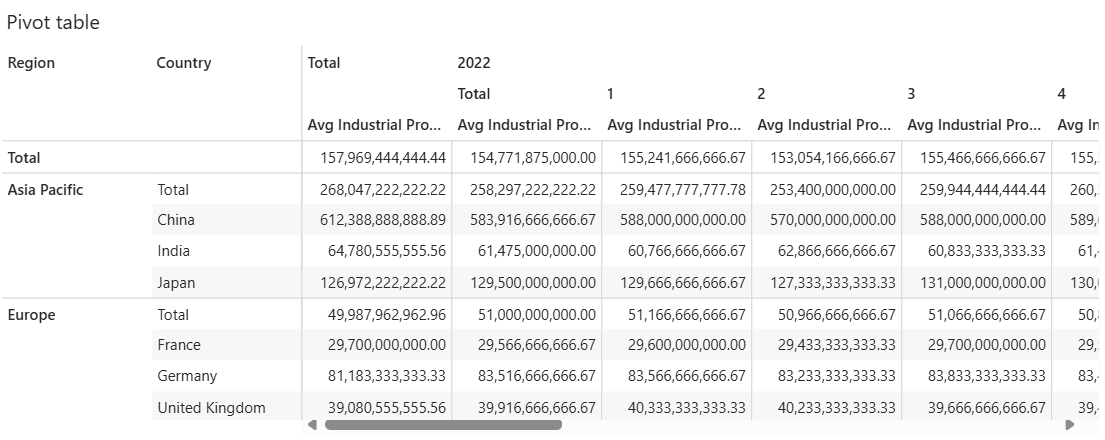

In [10]:
session.widget

## 2. CPI by Country (2022–2024)

This line chart tracks **CPI** (a proxy for the inflation rate) for each country
across 2022, 2023, and 2024. Each line is one country, so it's easy to compare both
the *level* of inflation and the *direction* it's moving.

**What the trend shows:**

- Most countries see CPI **falling over the three years**, suggesting a broad
  cooling of inflation after 2022.
- **Brazil** starts highest (~9.3 in 2022) but drops sharply, ending around 4.4 by
  2024 — one of the steepest declines.
- The **United States** and **Germany** also fall substantially, both starting near
  8 in 2022 and dropping to roughly 2–3 by 2024.
- **Japan** is the exception: it stays low and even *rises* slightly into 2023
  before easing, reflecting its very different inflation environment.
- **China** sits at the bottom throughout, with CPI dropping close to zero — pointing
  toward near-flat prices or mild deflationary pressure.

Open the notebook in JupyterLab with the Atoti JupyterLab extension enabled to build this widget.
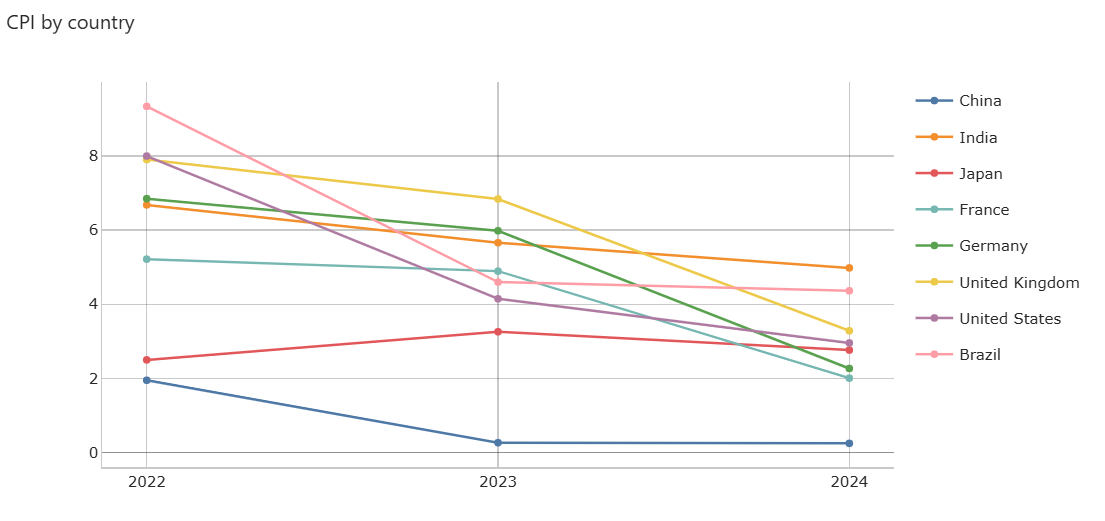

In [11]:
session.widget

## 3. CPI by Region (2022–2024)

This is the same CPI measure as above, but **aggregated up to the region level**.
By collapsing individual countries into their regions, the chart cuts through the
noise and shows the broader inflation picture for Asia Pacific, Europe, North
America, and South America.

**What the trend shows:**

- **South America** begins with the highest regional CPI (~9.3 in 2022), driven
  largely by Brazil, then falls sharply and flattens out around 4.4.
- **North America** and **Europe** track closely in the middle, both declining over
  the period — though Europe's drop accelerates most in the final year, falling
  *below* North America by 2024.
- **Asia Pacific** stays the lowest throughout, reflecting the muted inflation of
  China and Japan.
- The overall message mirrors the country chart: a **shared downward trend in
  inflation**, but with South America starting much higher and Asia Pacific staying
  consistently subdued.

This view is a good example of the value of the `Region → Country` hierarchy — the
exact same measure tells a cleaner, higher-level story simply by changing the level
at which it's aggregated.

Open the notebook in JupyterLab with the Atoti JupyterLab extension enabled to build this widget.
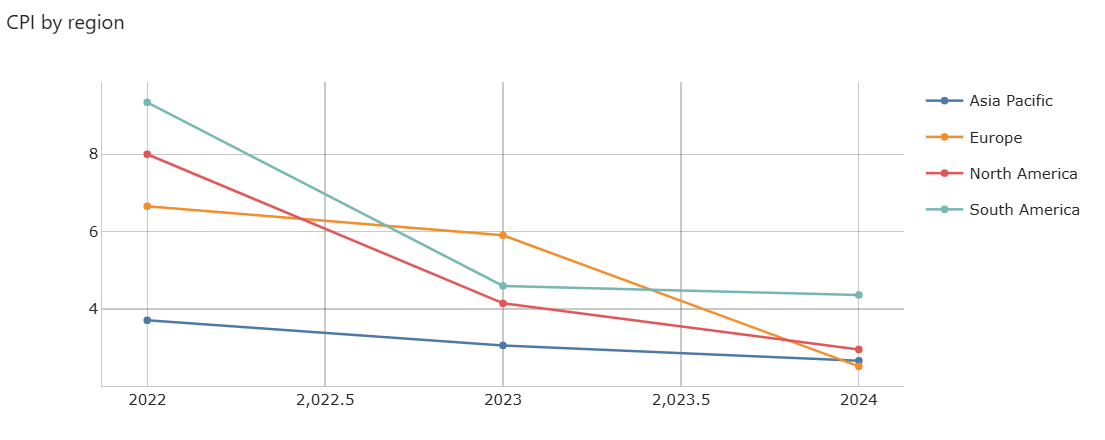

In [13]:
session.widget

## 4. GDP by Country, Stacked by Year

This stacked bar chart shows total **GDP** for each `Region, Country` combination,
with each bar split by year (2022, 2023, 2024). The total bar length is the
three-year sum, while the coloured segments show each year's contribution.

**How to read it:**

- Each **bar** is one country (labelled with its region for context).
- The **three colours** stack each year's GDP, so a longer bar means a larger
  economy over the period, and roughly equal segments mean steady year-on-year output.

**What stands out:**

- The **United States** has by far the largest GDP, with a combined total above
  **80M** (in the dataset's units) — roughly 1.5× the next largest.
- **China** is second (~55M combined), the dominant economy within Asia Pacific.
- The remaining countries cluster much lower (roughly **6M–14M** each), with
  Germany, Japan, and the UK forming a middle tier and Brazil, France, and India
  at the smaller end.
- For every country the three yearly segments are fairly even, indicating **stable
  GDP across 2022–2024** rather than sharp growth or contraction.

Open the notebook in JupyterLab with the Atoti JupyterLab extension enabled to build this widget.
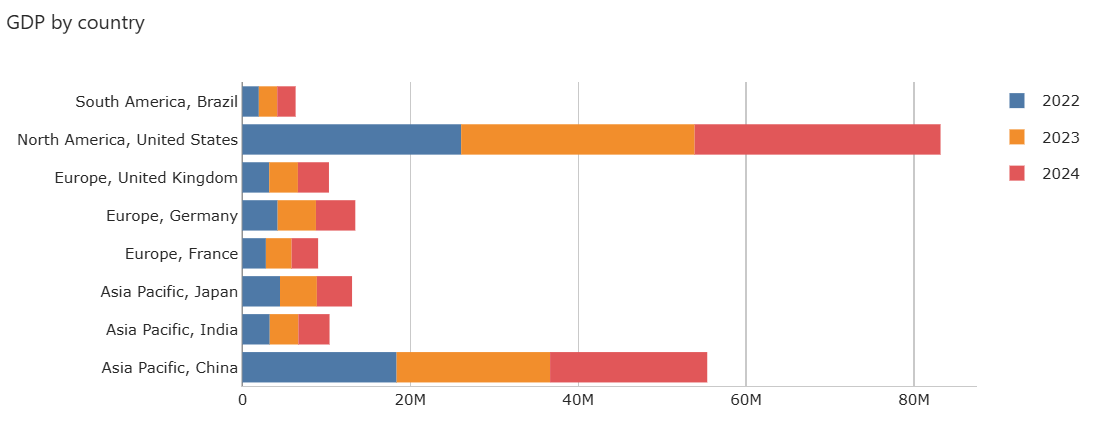

In [14]:
session.widget